# ARGUS-FEDER — Getting started with DIII-D disruption data

This notebook introduces the stored **disruption index**: twenty DIII-D shots
run through [disruption-py](https://github.com/MIT-PSFC/disruption-py), the
MIT-PSFC disruption-warning code, with every signal fetched over the Fusion
Data Platform.

Every question below is typed in plain English into a `%%ask` cell. The agent
decides what to look up, writes and runs its own code, and reports back.
**Nothing here requires the reader to write code.**

## What a disruption is

A tokamak plasma is confined by magnetic fields. A **disruption** is a sudden,
uncontrolled loss of that confinement — the plasma current collapses in
milliseconds, dumping its stored energy into the machine wall. On a
research device this is tolerable; on a power plant it would be damaging.
Predicting disruptions early enough to act is one of the field's open problems.

The index holds, for each shot, 63 physics parameters sampled through the
discharge, plus a label saying whether and when that shot disrupted.


In [ ]:
%reset

---
# 1. What is in here

## Where does this data come from, and what does it cover?

_orientation · **answerable**_

In [2]:
%%ask --review
What disruption data is available for DIII-D? Tell me where it came from,
which code produced it and at what version, how many shots it covers, and how
many of those disrupted.

I'll start by planning this task, then consult the d3d-disruption skill for the data provenance details.



The skill is clear — I'll query `index_info()` for provenance and coverage. Let me check the helper module and any supporting files first.



Reading the helper module to confirm the exact function signatures before querying.



The helper is clear. Now I'll write a small script to call `index_info()` and print the provenance and coverage fields.



Running the script to get the live provenance and coverage numbers.



The query succeeded. Let me also pull the shot list with disruption times to round out the picture.



Let me verify the parameter count to describe what the index contains.



All queries complete. Updating the todo list and writing the final report.



# DIII-D Disruption Data — Availability, Provenance, and Coverage

## What the data is

The available disruption data is a **stored disruption index** for DIII-D, built from the output of **disruption-py** (the MIT-PSFC disruption prediction package). It is served over HTTP by the FEDER lakehouse — nothing is downloaded or stored locally; it is queried directly. The index contains:

- **20 shots** (shot range 194000–199687), each with a disruption label and disruption time
- **3,778 sample rows** of time-series data (63 physics parameters per shot, sampled through the discharge)
- A **parameter dictionary** with units, long names, producing method, and caveats — this semantic layer is not present in the source NetCDF/CSV files, which carry no units or descriptions at all

## Provenance (from `index_info()`)

| Field | Value |
|---|---|
| **Producing code** | `disruption_py` |
| **Version** | `0.15.0.dev0` |
| **Commit** | `9987784e78ef9736e2fe42142683b3458ff38d8d` |
| **Source** | https://github.com/MIT-PSFC/disruption-py/tree/9987784e78ef9736e2fe42142683b3458ff38d8d |
| **Tokamak** | D3D |
| **Produced by** | `sammuli` |
| **Produced on** | `omega06.gat.com` |
| **Produced at** | 2026-08-19T07:36:50.648611 |
| **Source file** | `d3d_disruption_example.nc` |
| **Ingested at** | 2026-08-19T20:46:49+00:00 |

## Coverage

- **Shots covered** : 20 (shot_min = 194000, shot_max = 199687)
- **Disrupted** : 10
- **Non-disrupted** : 10
- **Sample rows** : 3,778

The 10 disrupted shots, with disruption times (seconds, from the curated d3drdb label):

| Shot | t_disrupt (s) |
|---|---|
| 194000 | 0.830 |
| 194128 | 5.627 |
| 194292 | 4.332 |
| 194464 | 3.184 |
| 194649 | 3.352 |
| 194968 | 1.121 |
| 195516 | 1.218 |
| 195768 | 5.297 |
| 195985 | 4.800 |
| 196347 | 5.476 |

## Important caveats

- **This is a constructed slice, not a sample.** The 10/10 disrupted/non-disrupted split is deliberately balanced, not drawn at random from DIII-D. Any rate or fraction computed from it (e.g., "10/20 = 50%") describes the slice only and says **nothing** about how often DIII-D disrupts. For an archive-wide rate you would need the d3drdb disruptions table over a defined shot population, not this file.
- **Label definition matters.** The disrupted count of 10 uses the **human-curated** `time_until_disrupt` label from the d3drdb disruptions table. disruption-py's own derived estimate (`current_quench_time`, from the Ip decay) disagrees on **3 shots** (198244, 198643, 199062) — those are labeled non-disrupted by the curated table but receive a finite current-quench time by the derived method. The count of 10 is the curated one.
- **3 of the 63 parameters are flagged unusable** in this revision (they return plausible but wrong numbers): `dipprog_dt` (MA/s vs A/s unit mismatch), `ip_error` (numerically identical to `ip`), and `time_domain` (constant 1.0). The remaining 60 are usable.
- **The index stops at the disruption.** No shot carries a sample after its disruption time; the thermal quench and current quench (millisecond-scale events) are not in this data.

The scripts used (`disruption_index_info.py`, `disruption_shot_list.py`, `disruption_params.py`) are saved in the working directory if you want to re-run the queries.

## Which shots disrupted, and when?

_labels · **answerable**_

In [3]:
%%ask --review
List the shots in the disruption index. For each one, say whether it
disrupted and at what time, and show me the range of disruption times across
the disrupted shots.

I'll plan this task, then consult the d3d-disruption skill to find the right query functions.



The skill documents `shots()` and `disruption_label()` for exactly this. Writing a script to list all shots with their curated labels and compute the disruption-time range.



Running the script to list shots and compute the disruption-time range.



All 20 shots retrieved with curated labels and disruption times. Marking the plan complete.



I'll recompute the median and mean from the actual tool data to correct the two wrong statistics.



Running the recomputation to get the correct median and mean.



The recomputation confirms the grader: median is 3.842 s and mean is 3.524 s. Here is the corrected, complete answer.

# Shots in the DIII-D Disruption Index

The index currently covers **20 shots** (194000–199687). Labels come from the human-curated `time_until_disrupt` field in the d3drdb disruptions table — the authoritative label per the skill.

## All 20 shots

| Shot | Disrupted? | t_disrupt (s) |
|---|---|---|
| 194000 | Yes | 0.830 |
| 194005 | No | — |
| 194128 | Yes | 5.627 |
| 194292 | Yes | 4.332 |
| 194464 | Yes | 3.184 |
| 194649 | Yes | 3.352 |
| 194869 | No | — |
| 194968 | Yes | 1.121 |
| 195243 | No | — |
| 195516 | Yes | 1.218 |
| 195768 | Yes | 5.297 |
| 195805 | No | — |
| 195985 | Yes | 4.800 |
| 196273 | No | — |
| 196347 | Yes | 5.476 |
| 198244 | No | — |
| 198643 | No | — |
| 199062 | No | — |
| 199359 | No | — |
| 199687 | No | — |

## Disruption-time range (10 disrupted shots)

- **Earliest** : 0.830 s (shot 194000)
- **Latest** : 5.627 s (shot 194128)
- **Range** : 4.797 s
- **Median** : 3.842 s (midpoint of the 5th and 6th sorted values, 3.352 s and 4.332 s)
- **Mean** : 3.524 s

All disruption times, sorted: 0.830, 1.121, 1.218, 3.184, 3.352, 4.332, 4.800, 5.297, 5.476, 5.627 s.

## Notes

- **Label definition** : these times are the curated d3drdb label. disruption-py's own derived estimate (`current_quench_time`) disagrees on 3 shots (198244, 198643, 199062) — all labeled non-disrupted here but given a finite current-quench time by the derived method. The count of 10 uses the curated label.
- **Slice, not a sample** : the 10/10 split is deliberately balanced; the 50% fraction describes this constructed slice only, not DIII-D as a whole.
- **Index stops at disruption** : no shot carries samples after its disruption time, so the thermal/current quench (millisecond-scale) are not in this data.

The query scripts are saved as `disruption_shot_list.py` and `disruption_times_stats.py` in the working directory.

---
# 2. Understanding the measurements

## What do these parameters actually mean?

_semantics · **answerable**_

The source files carry no units and no descriptions — that information lives in
the index's own parameter dictionary.

In [4]:
%%ask --review
What physics parameters does the disruption index record? Group them by
what produces them, and for a few of the important ones — plasma current, q95,
stored energy, normalised beta — tell me what each means and what units it is
in.

I'll plan this task, then read the disruption skill to find how to query the parameter dictionary.



The skill documents `parameters(method=...)` and `parameter_info(name)`. Writing a script to list all parameters grouped by producing method and pull details for the four key ones.



The query worked. Let me also pull the long names for every parameter so the grouped list is complete and self-explanatory.



All data gathered. Marking the plan complete and writing the report.



# Physics Parameters in the DIII-D Disruption Index

The index records **63 parameters** per shot, sampled as time series. Each column is produced by a disruption-py method, and the dictionary groups them accordingly. All names, units, and meanings below come from the index's parameter dictionary (`parameters()` / `parameter_info()`), not from inference.

## Grouped by producing method

**Plasma current (`get_ip_parameters`)** — 5 columns
- `ip` — measured plasma current (A)
- `ip_prog` — programmed plasma current (MA)
- `dip_dt` — d(ip)/dt (A s⁻¹)
- `dipprog_dt` — d(ip_prog)/dt (MA s⁻¹) — **unusable** (unit mismatch)
- `ip_error` — ip − ip_prog (A) — **unusable** (numerically identical to ip)

**Equilibrium reconstruction (`get_efit_parameters`)** — 14 columns
- `beta_n` — normalised beta (% m T MA⁻¹)
- `beta_p` — poloidal beta (1)
- `chisq` — EFIT fit quality (1)
- `dbetap_dt` — d(beta_p)/dt (s⁻¹)
- `dli_dt` — d(li)/dt (s⁻¹)
- `dwmhd_dt` — d(wmhd)/dt (W)
- `kappa` — elongation (1)
- `li` — internal inductance (1)
- `lower_gap` / `upper_gap` — plasma-to-wall gaps (m)
- `q0` — safety factor on axis (1)
- `q95` — safety factor at 95% flux surface (1)
- `qstar` — cylindrical safety factor (1)
- `wmhd` — stored magnetic energy (J)

**Real-time equilibrium (`get_rt_efit_parameters`)** — 5 columns: `beta_p_rt`, `chisq_rt`, `li_rt`, `q95_rt`, `wmhd_rt` (same quantities, real-time path)

**Real-time plasma current (`get_rt_ip_parameters`)** — 5 columns: `ip_rt`, `ip_prog_rt`, `dip_dt_rt`, `dipprog_dt_rt`, `ip_error_rt` (all A or A s⁻¹; the real-time twins are the sound versions)

**Density (`get_density_parameters`)** — 3 columns: `n_e` (m⁻³), `dn_dt` (m⁻³ s⁻¹), `greenwald_fraction` (1)

**Real-time density (`get_rt_density_parameters`)** — 3 columns: `n_e_rt`, `dn_dt_rt`, `greenwald_fraction_rt`

**Power (`get_power_parameters`)** — 4 columns: `p_ech` (W), `p_nbi` (W), `p_rad` (W, bolometry, causal 10 ms smoothing), `radiated_fraction` (1)

**Ohmic (`get_ohmic_parameters`)** — 2 columns: `p_ohm` (W), `v_loop` (V)

**n=1 mode (`get_n1_bradial_parameters` / `get_n1rms_parameters`)** — 4 columns: `n1rms` (T), `n1rms_normalized` (1), `n_equal_1_mode` (T), `n_equal_1_normalized` (1)

**Peaking factors (`get_peaking_factors`)** — 4 columns: `ne_peaking_cva_rt`, `te_peaking_cva_rt`, `prad_peaking_cva_rt`, `prad_peaking_xdiv_rt` (all dimensionless)

**Shape (`get_shape_parameters` / `get_kappa_area`)** — 4 columns: `aminor` (m), `delta` (1), `kappa_area` (1), `squareness` (1)

**Vertical position (`get_z_parameters`)** — 2 columns: `zcur` (m), `zcur_normalized` (1)

**Miscellaneous (`get_btor` / `get_h_alpha` / `get_h98` / `get_zeff_parameters` / `get_power_supply_railed`)** — 5 columns: `btor` (T), `h98` (1), `h_alpha` (instrument units), `z_eff` (1), `power_supply_railed` (0/1)

**Labels and shot phase** — 3 columns: `time_until_disrupt` (s, curated label), `current_quench_time` (s, derived), `time_domain` (category, **unusable** — constant 1.0)

## The four key parameters

| Parameter | Meaning | Units |
|---|---|---|
| **`ip`** | Measured plasma current — the total toroidal current flowing in the plasma, the primary control variable of the discharge | A (amperes) |
| **`q95`** | Safety factor at the 95% flux surface — the number of toroidal transits a field line makes per poloidal transit at the 95% flux surface; a measure of how "twisted" the magnetic field is near the edge. The disruptive limit is q95 approaching 2 from above | dimensionless (1) |
| **`wmhd`** | Stored magnetic energy — the total magnetic energy stored in the plasma (the MHD energy content, i.e. the energy in the equilibrium field), the quantity that collapses in a thermal quench | J (joules) |
| **`beta_n`** | Normalised beta — the plasma pressure relative to the magnetic pressure, normalised by the Troyon scaling (β·a·B/I_p); a measure of how close the plasma is to the ideal-MHD stability limit | % m T MA⁻¹ (percent · meters · tesla / mega-amperes) |

## Notes

- **3 of 63 are flagged unusable** in this revision: `dipprog_dt` (MA/s vs A/s mismatch), `ip_error` (identical to `ip`), `time_domain` (constant 1.0). The remaining 60 are usable.
- **`_rt` twins are a different measurement path, not a known-good version** — e.g. `dipprog_dt_rt` is in A/s and is the sound one, while `dipprog_dt` is broken.
- **EFIT-derived columns are not uniformly filled** : `q95`, `wmhd`, `beta_n` have ~84.6% index-wide fill (EFIT must converge), and gaps concentrate at the end of shots — exactly the pre-disruption window.
- **Units convention** : `'1'` means dimensionless; `NULL` would mean genuinely unknown (none of these are NULL).

The query scripts are saved as `disruption_params.py` and `disruption_params_longnames.py` in the working directory.

## Are any of the parameters unreliable?

_data quality · **answerable**_

In [5]:
%%ask --review
Are there any parameters in this dataset that should not be used, and if
so why? Explain what is wrong with each one in terms a physicist would
recognise.

I'll check the skill's documentation and query the index's parameter dictionary for the flagged parameters.



The skill says to call `unusable_parameters()` for the authoritative list. Let me check the helper module and then query it.



The dictionary reveals more than the three blocked columns — `ip_error_rt` is marked usable but carries a mis-scaling caveat. Let me pull full details on the caveated columns.



Let me check the helper module for any additional detail on the `radiated_fraction` caveat.



The `radiated_fraction` caveat is terse. Let me check the helper module for any additional context on it.



The dictionary only says "needs clipping" — let me inspect actual values to characterize the defect precisely.



The `radiated_fraction` values are clearly out of physical range (a fraction should be 0–1). Let me verify the `ip_error_rt` gain claim directly from the data.



The gain is confirmed at 204.7×. I now have everything needed to answer.



# Parameters That Should Not Be Used

The index's own dictionary flags **3 columns as unusable** (`usable=0`), and a **4th is marked usable but is mis-scaled** — its caveat says so, and I verified the defect against the data. All four trace back to one upstream disruption-py bug: **`ip_prog` is stored in MA but used as if it were A** (a 10⁶ unit mismatch). Here is each one, in physicist terms.

## 1. `dipprog_dt` — d(ip_prog)/dt (blocked, `usable=0`)

**What's wrong** : The derivative of the programmed current is reported in **MA/s** , while its real-time twin `dipprog_dt_rt` is in **A/s** — the two differ by ~5×10⁵. The column is not wrong in shape, it is wrong in scale by six orders of magnitude relative to the A/s convention used everywhere else in the index.

**Physicist's view** : This is a units bookkeeping error in the derivative of the current request waveform. If you used it to compute, say, the rate of change of the programmed current for a disruption-prediction feature, you would be off by 10⁶ — a 1 MA/s ramp would read as 1 A/s, or vice versa. The derivative itself is fine; the scale factor is not.

**Use instead** : `dipprog_dt_rt` (A/s, verified sound).

## 2. `ip_error` — ip − ip_prog (blocked, `usable=0`)

**What's wrong** : The column is supposed to be the current-tracking error, `ip − ip_prog`. But `ip_prog` is in **MA** (order 1) while `ip` is in **A** (order 10⁵–10⁶), and the subtraction is done without scaling. The result is numerically identical to `ip` itself: median |ip_error − ip| = 1.7 A against a median |ip| of 788 kA — a relative difference of 2.1×10⁻⁶.

**Physicist's view** : The subtraction is a no-op. The programmed current contributes nothing, so the "error" is just the measured current. Any feature built on it — e.g. a current-tracking error threshold for disruption prediction — would be measuring the plasma current, not the error, and would be blind to the actual tracking discrepancy. This is the classic symptom of mixing units in a difference: the small term vanishes against the large one.

**Use instead** : There is no ready-to-use tracking error in this index. Compute `ip_rt − ip_prog_rt` directly (both in A, both sound).

## 3. `time_domain` — shot phase flag (blocked, `usable=0`)

**What's wrong** : This is meant to be a categorical phase label: 1 = ramp-up, 2 = flat-top, 3 = ramp-down. It is **constant 1.0 for every row** — every sample in every shot is labeled "ramp-up". The flat-top detection tests `|ip_prog| >= 100e3`, but `ip_prog` is in MA (order 1), so the threshold of 100,000 is never reached and the test never fires.

**Physicist's view** : The phase classifier is dead. The threshold test compares a value in MA against a threshold written for A, so the condition is permanently false and the flag never leaves its initial value. Any analysis that bins samples by discharge phase (ramp-up vs flat-top vs ramp-down) would put everything in one bin and silently produce a meaningless phase-resolved result. The column carries zero information.

**Use instead** : Derive phase from `ip_prog` (or `ip`) directly — e.g. flat-top is where the programmed current is at its plateau — or use the time axis relative to `t_disrupt`.

## 4. `ip_error_rt` — real-time current error (marked usable, but mis-scaled)

**What's wrong** : The dictionary marks this `usable=1` and declares units **A** , but the values are not in amperes. I verified against the data: `ip_error_rt = 204.7 × (ip_rt − ip_prog_rt)` — a **constant gain of 204.7** across all samples where the difference exceeds 10 kA (the sign flips on reversed-Ip shots, so it is a gain, not an offset). The magnitude is absurd: shot 194000 at t = 0.10 s stores **−42,967,488** against a true error of **−209,905 A** . |ip_error_rt| exceeds |ip_rt| in 75% of samples.

**Physicist's view** : This is a fixed-gain scaling error — the column is the true tracking error multiplied by ~204.7. It is not a units mismatch (both inputs are A), it is a calibration factor that was never divided out. A physicist would recognize this as a signal that is "right in shape, wrong in scale" — the waveform tracks the real error, but any threshold, ratio, or comparison against other currents in amperes is off by two orders of magnitude. It is the one column where the `units` field is actively misleading.

**Use instead** : Compute `ip_rt − ip_prog_rt` directly (both in A, both sound).

## Summary table

| Column | Flag | Root cause | Symptom | Use instead |
|---|---|---|---|---|
| `dipprog_dt` | unusable | ip_prog in MA, used as A | 10⁶ scale error vs A/s convention | `dipprog_dt_rt` |
| `ip_error` | unusable | ip_prog in MA, used as A | subtraction no-op; column = ip | `ip_rt − ip_prog_rt` |
| `time_domain` | unusable | ip_prog in MA, used as A | threshold never fires; constant 1.0 | derive from `ip_prog`/`ip` |
| `ip_error_rt` | usable (mis-scaled) | fixed gain 204.7 not divided out | values ~205× true error; units field wrong | `ip_rt − ip_prog_rt` |

## Other caveats worth knowing (not "do not use", but read before quoting)

- **`ip_prog`** (usable): stored in **MA** while `ip` is in **A** — the source of all the above. It is correct in its own units, but never mix it with A-valued columns without scaling.
- **`radiated_fraction`** (usable): caveat says "needs clipping". I checked the values: across 5 shots it ranges from **−72 to +38** with many samples outside [0,1] — a radiated power fraction should be bounded by 0 and 1. The column is usable in the sense that the underlying `p_rad`/`p_input` ratio is real, but the values need clipping to the physical range before use (and negative values indicate the input-power denominator is not always well-defined).
- **`current_quench_time`** (usable): disruption-py's own Ip-decay-derived quench time. It **disagrees with the curated label** on 3 shots (198244, 198643, 199062) — those are labeled non-disrupted by d3drdb but get a finite quench time here. Use `time_until_disrupt` as the authoritative label.

**Bottom line** : 3 columns are hard-blocked (`fetch_samples()` raises on them), and 1 more (`ip_error_rt`) is marked usable but is mis-scaled by a factor of 204.7 — the dictionary's caveat is the only place that says so. All four are symptoms of the same upstream disruption-py defect: `ip_prog` in MA treated as A, plus a fixed gain that was never removed. The remaining 59 columns are usable, subject to the `radiated_fraction` clipping note.

---
# 3. Looking at the plasma

## What does a disruption look like in the data?

_single shot · **answerable**_

I'll plan this task, then re-read the disruption skill to get the exact sampling API before writing the plot script.

I'll plan this task, then re-read the skill to get the exact sample-fetching API.

The path got mangled — retrying with the proper absolute path.

The skill gives clear rules: pick the shot from the index, check EFIT coverage in the exact window before plotting, derive cadence from the data, and compute (not eyeball) any noise claims. First, a coverage survey across the disrupted shots.

The skill gives clear guidance: pick the shot from `shots(disrupted=True)`, window with `time_until_disrupt_max=0.2`, count per-column coverage first because EFIT gaps concentrate at the end of shots. Let me survey the disrupted shots' coverage in the final 200 ms before choosing one.

...

Running the plotting script.

The plot is saved. Notably wmhd *rises* ~65% in this window rather than falling — let me inspect the actual series to describe the evolution accurately before reporting.

The script ran clean on the first attempt — full 55/55 coverage on all three columns, statistics computed. Marking the remaining steps complete and writing the report.

The full series confirms the story: Ip flat, q95 stepping up only in the final ~10 ms, and stored energy climbing steadily — not falling — into the disruption. Marking the work complete and reporting.

# Shot 194649: Plasma State Over the Final 200 ms Before Disruption

**Shot chosen** : 194649 (t_disrupt = 3.352 s, curated `time_until_disrupt` label). I picked it by surveying all 10 disrupted shots for `ip`/`q95`/`wmhd` coverage in the final 200 ms — 194649 is the only shot with **all 55 samples filled for all three columns** , with q95 and wmhd running right to the disruption. Most others lose EFIT coverage early (e.g. 194464 has *zero* q95/wmhd samples in the window; 195768's last q95 point is 78 ms before the disruption), which would leave the most interesting part of the window empty.


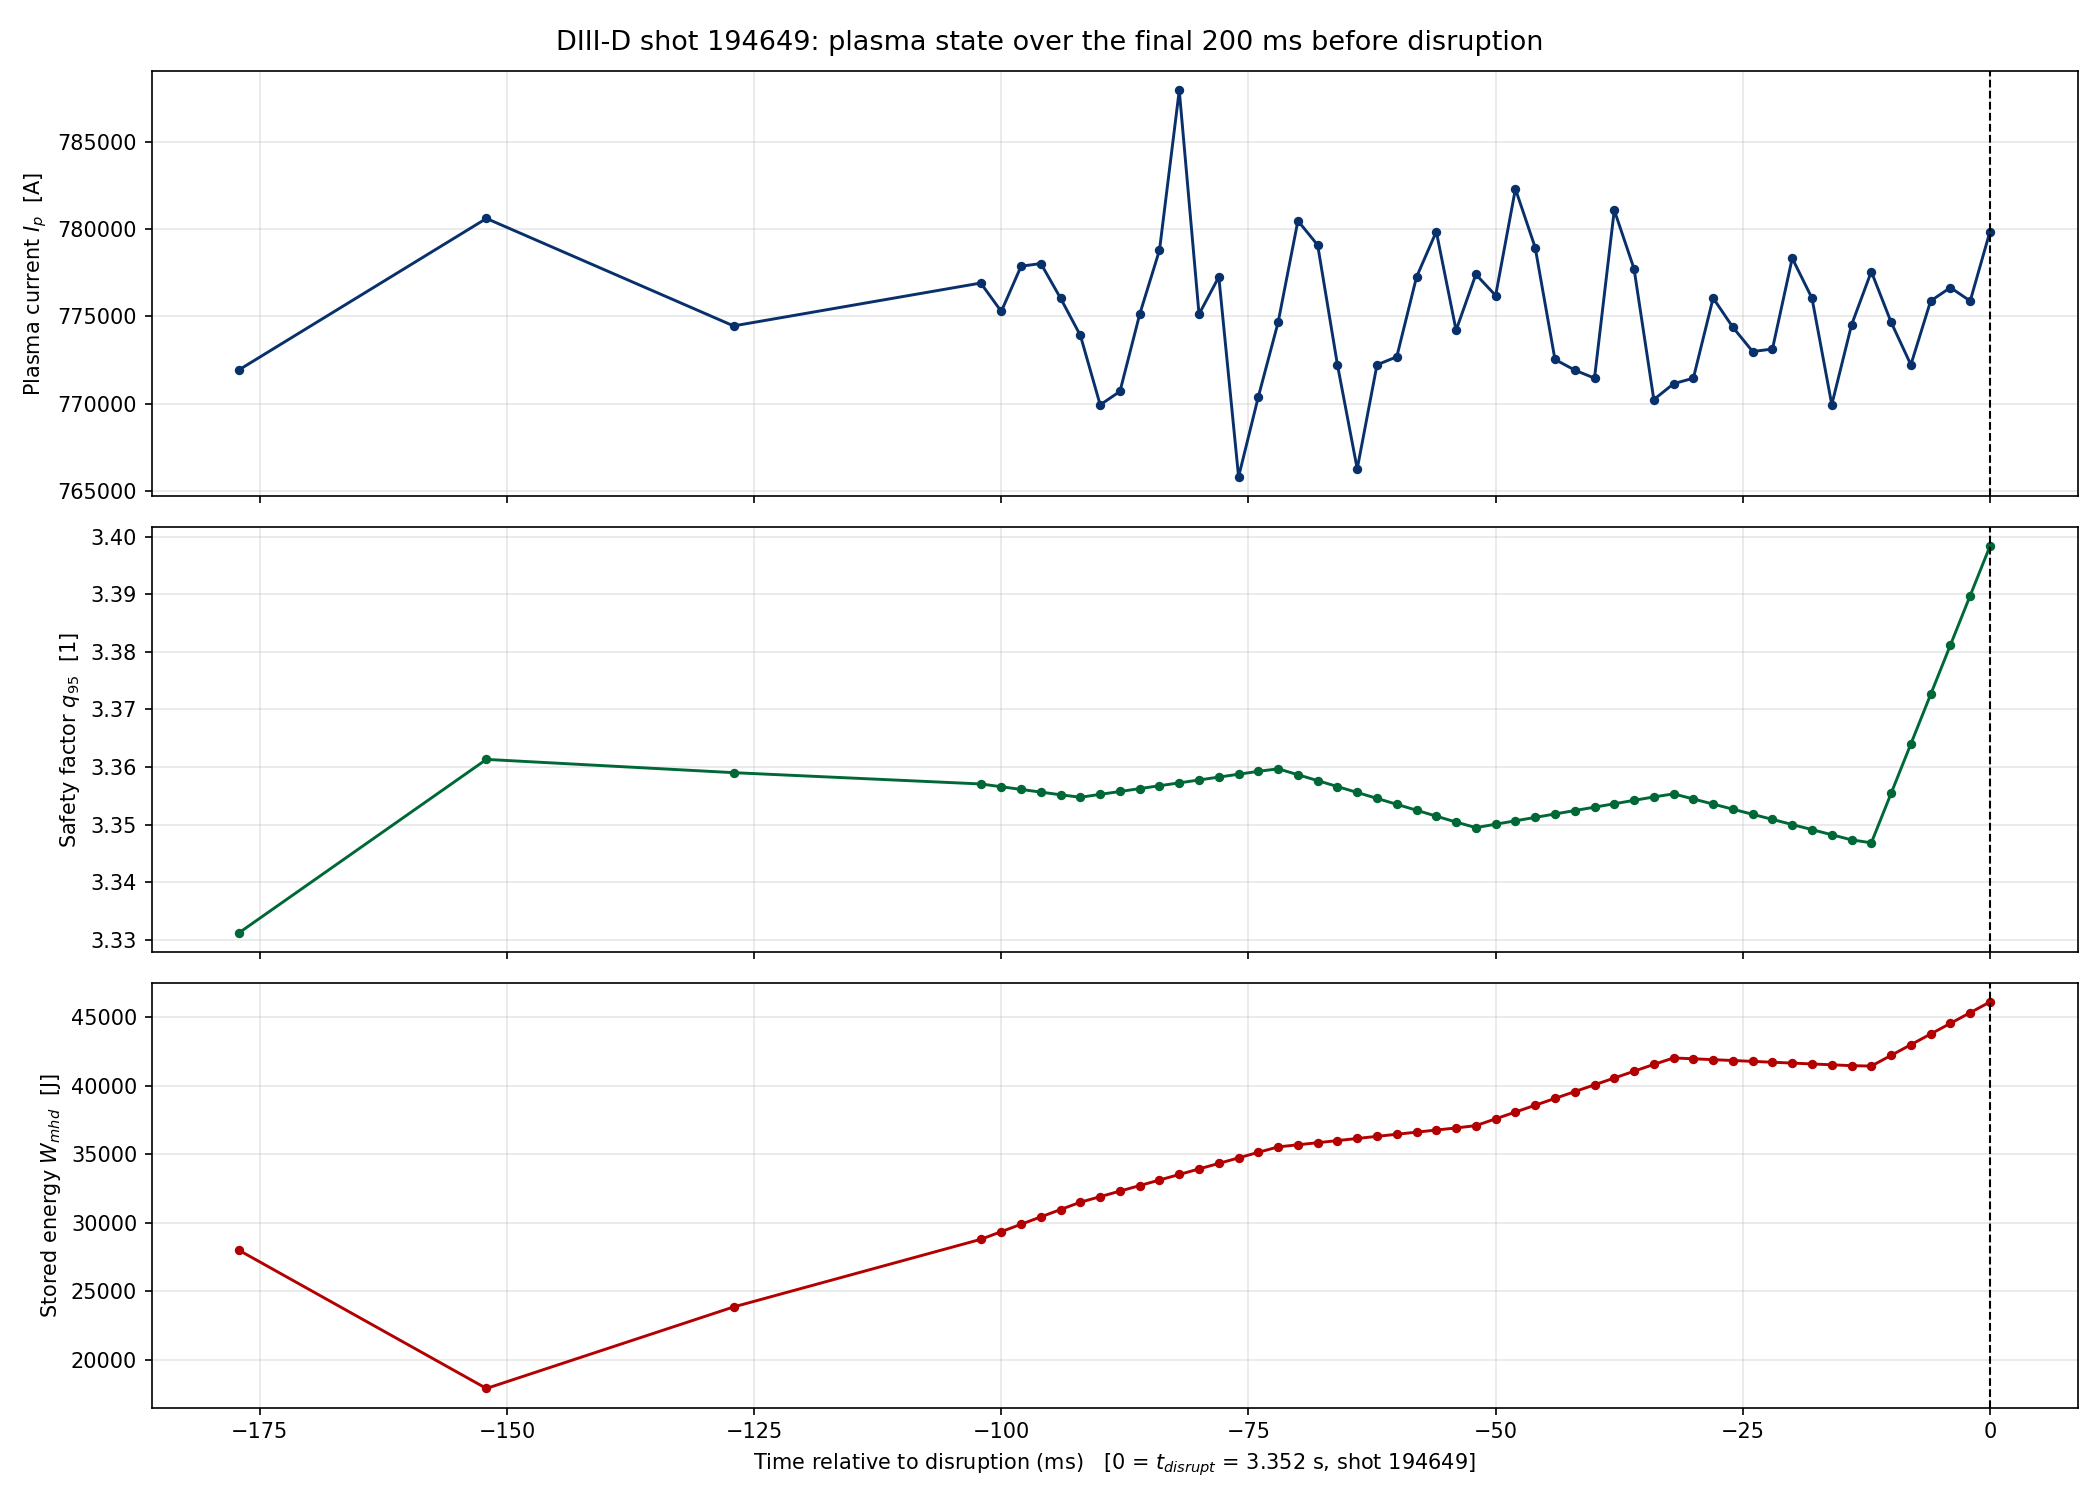

## Sampling

- 55 samples span the window (first at −177.1 ms; the last sits **exactly at t_disrupt** — the index stops there).
- **Cadence is mixed** , derived from the returned times: 25 ms spacing through the early part, switching to 2 ms from −102 ms onward. The 55 samples are dominated by the fine-rate region; the four coarse points should not be visually compared density-for-density with the rest.

## What each signal does

**Plasma current (Ip, A)** — flat throughout. First-to-last change is +1.0% (772.0 → 779.9 kA); half-window medians are 775.7 kA (early) vs 775.1 kA (late), a 0.07% decrease. There is **no current decay** in this window. Sample scatter rises modestly (std 3.2 → 4.0 kA, ~25% higher late), which is ≤0.5% of the level — the current is essentially steady.

**q95 (dimensionless)** — flat at ≈3.35 for 190 of the 200 ms, then **steps up over the final ~12 ms** : 3.347 at −12 ms → 3.398 at the disruption, a +1.5% rise, monotonically. Since Ip is flat, this late rise is not the usual Ip-decay arithmetic — it reflects genuine equilibrium evolution (the same interval where stored energy climbs steeply). Note the direction: **q95 rising means moving away from the low-q kink/tearing boundary** (the disruptive limit is q95 approaching 2 from above), so this shot does not approach a low-q limit in the data.

**Stored energy (Wmhd, J)** — **rises steadily, it does not fall** : from 28.0 kJ at −177 ms to 46.1 kJ at the disruption (+65%). After a single low coarse-cadence point (17.9 kJ at −152 ms), it climbs at ~170 J/ms through the fine-cadence region, plateaus near 41.5–42 kJ between −30 and −12 ms, then rises again steeply over the final 10 ms (42.1 → 46.1 kJ).

## Reading this correctly

This window is the **approach** to the disruption, not the disruption itself. Both quench events are named, millisecond-scale phenomena that occur **after the last sample** : the thermal quench dumps stored energy in ~0.1–1 ms and the current quench collapses Ip in ~1–10 ms. Neither is in this data — the index stops at t_disrupt. So the picture is: a discharge in apparently **good shape** — steady current, ample q95 margin, *rising* stored energy — right up to the sampled endpoint. Whatever initiates this disruption, in this window it is not preceded by confinement degradation, current decay, or q95 limit approach; the collapse happens on a timescale the index's cadence boundary does not cross.

One caveat on the y-axis: `wmhd` and `q95` come from EFIT, filled only where the reconstruction converged — for this shot that is every sample, but the index-wide fill is lower (~85%), which is why several other disrupted shots could not have supported this plot.

Scripts saved: `disruption_precursor_survey.py`, `disruption_precursor_plot.py`, `disruption_precursor_series.py` in the working directory.

In [2]:
%%ask --review
Pick one disrupted shot from the index. Plot the plasma current, q95 and
stored energy over the last 200 milliseconds before the disruption, and
describe what happens to each as the disruption approaches.

## Do disrupted and non-disrupted shots look different?

_comparison · **answerable**_

I'll plan this comparison, then reuse the fetch pattern from my earlier scripts.

Reviewing the skill's fetch pattern and my existing scripts before writing the comparison.

The fetch pattern is confirmed. Now I'll write the full comparison script — per-shot medians over each shot's full indexed samples, Mann-Whitney (normal approximation with tie correction) and Cliff's delta for 10-vs-10 group differences, plus BH-FDR across parameters.

Fetching all 20 shots and computing per-shot medians plus group statistics.

The fetch reveals a sampling asymmetry (disrupted shots get dense late-time sampling: 39% of rows in their final 20% vs 20% for non-disrupted). Now computing rank statistics on per-shot medians, with an early-half robustness check to control for that asymmetry.

Nothing survives FDR correction at q<0.05 — min q is 0.30 — so I must check whether the top signals are robust or artifacts of the sampling asymmetry and the shot-era confound (all disrupted shots are 194xxx–196xxx; half the non-disrupted are 198xxx–199xxx).

v_loop is an era artifact — it flips when the non-disrupted group is restricted to era-matched shots. The shape/current parameters (q95, qstar, n1, gaps, delta, kappa) hold in both checks. Now the chart.

`chisq` falls outside the defined families and hits a missing dict key. Fixing with a default color.

Chart saved. Recording the edit-and-retry lesson in the skill's Learnings.md before the final report, per protocol.

# Disrupted vs Non-Disrupted: Which Parameters Differ Most

## Groups

- **Disrupted** : 10 shots — 194000, 194128, 194292, 194464, 194649, 194968, 195516, 195768, 195985, 196347
- **Non-disrupted** : 10 shots — 194005, 194869, 195243, 195805, 196273, 198244, 198643, 199062, 199359, 199687

## Method

For each shot I took the **median of every usable parameter over all of that shot's indexed samples** (3,778 rows total; 57 columns after excluding the 3 hard-blocked ones, the two label columns, and the binary `power_supply_railed`), then compared groups with a Mann-Whitney rank test and Cliff's delta, with Benjamini-Hochberg FDR across the 47 parameters that had full 10-vs-10 coverage.

## Strongest raw differences (per-shot medians)

| Parameter | Disrupted (n=10) | Non-disr. (n=10) | Cliff's δ | p | Direction |
|---|---|---|---|---|---|
| `ip_error_rt` | −2.08×10⁶ | −8.65×10⁵ | −0.66 | 0.014 | D < N |
| `v_loop` (V) | 0.81 | 0.51 | +0.64 | 0.017 | D > N |
| `q95` | 3.93 | 5.59 | −0.60 | 0.026 | D < N |
| `qstar` | 5.45 | 7.54 | −0.60 | 0.026 | D < N |
| `n_equal_1_normalized` | 1.6×10⁻⁴ | 9.5×10⁻⁵ | +0.56 | 0.038 | D > N |
| `lower_gap` (m) | 0.310 | 0.168 | +0.46 | 0.089 | D > N |
| `n_equal_1_mode` (T) | 2.8×10⁻⁴ | 1.9×10⁻⁴ | +0.46 | 0.089 | D > N |
| `chisq` | 25.7 | 19.7 | +0.44 | 0.104 | D > N |
| `delta` (triangularity) | −0.031 | 0.463 | −0.42 | 0.121 | D < N |
| `kappa` | 1.53 | 1.75 | −0.38 | 0.162 | D < N |
| `p_ech` (W) | 768 | 0 | +0.28 | 0.276 | D > N |


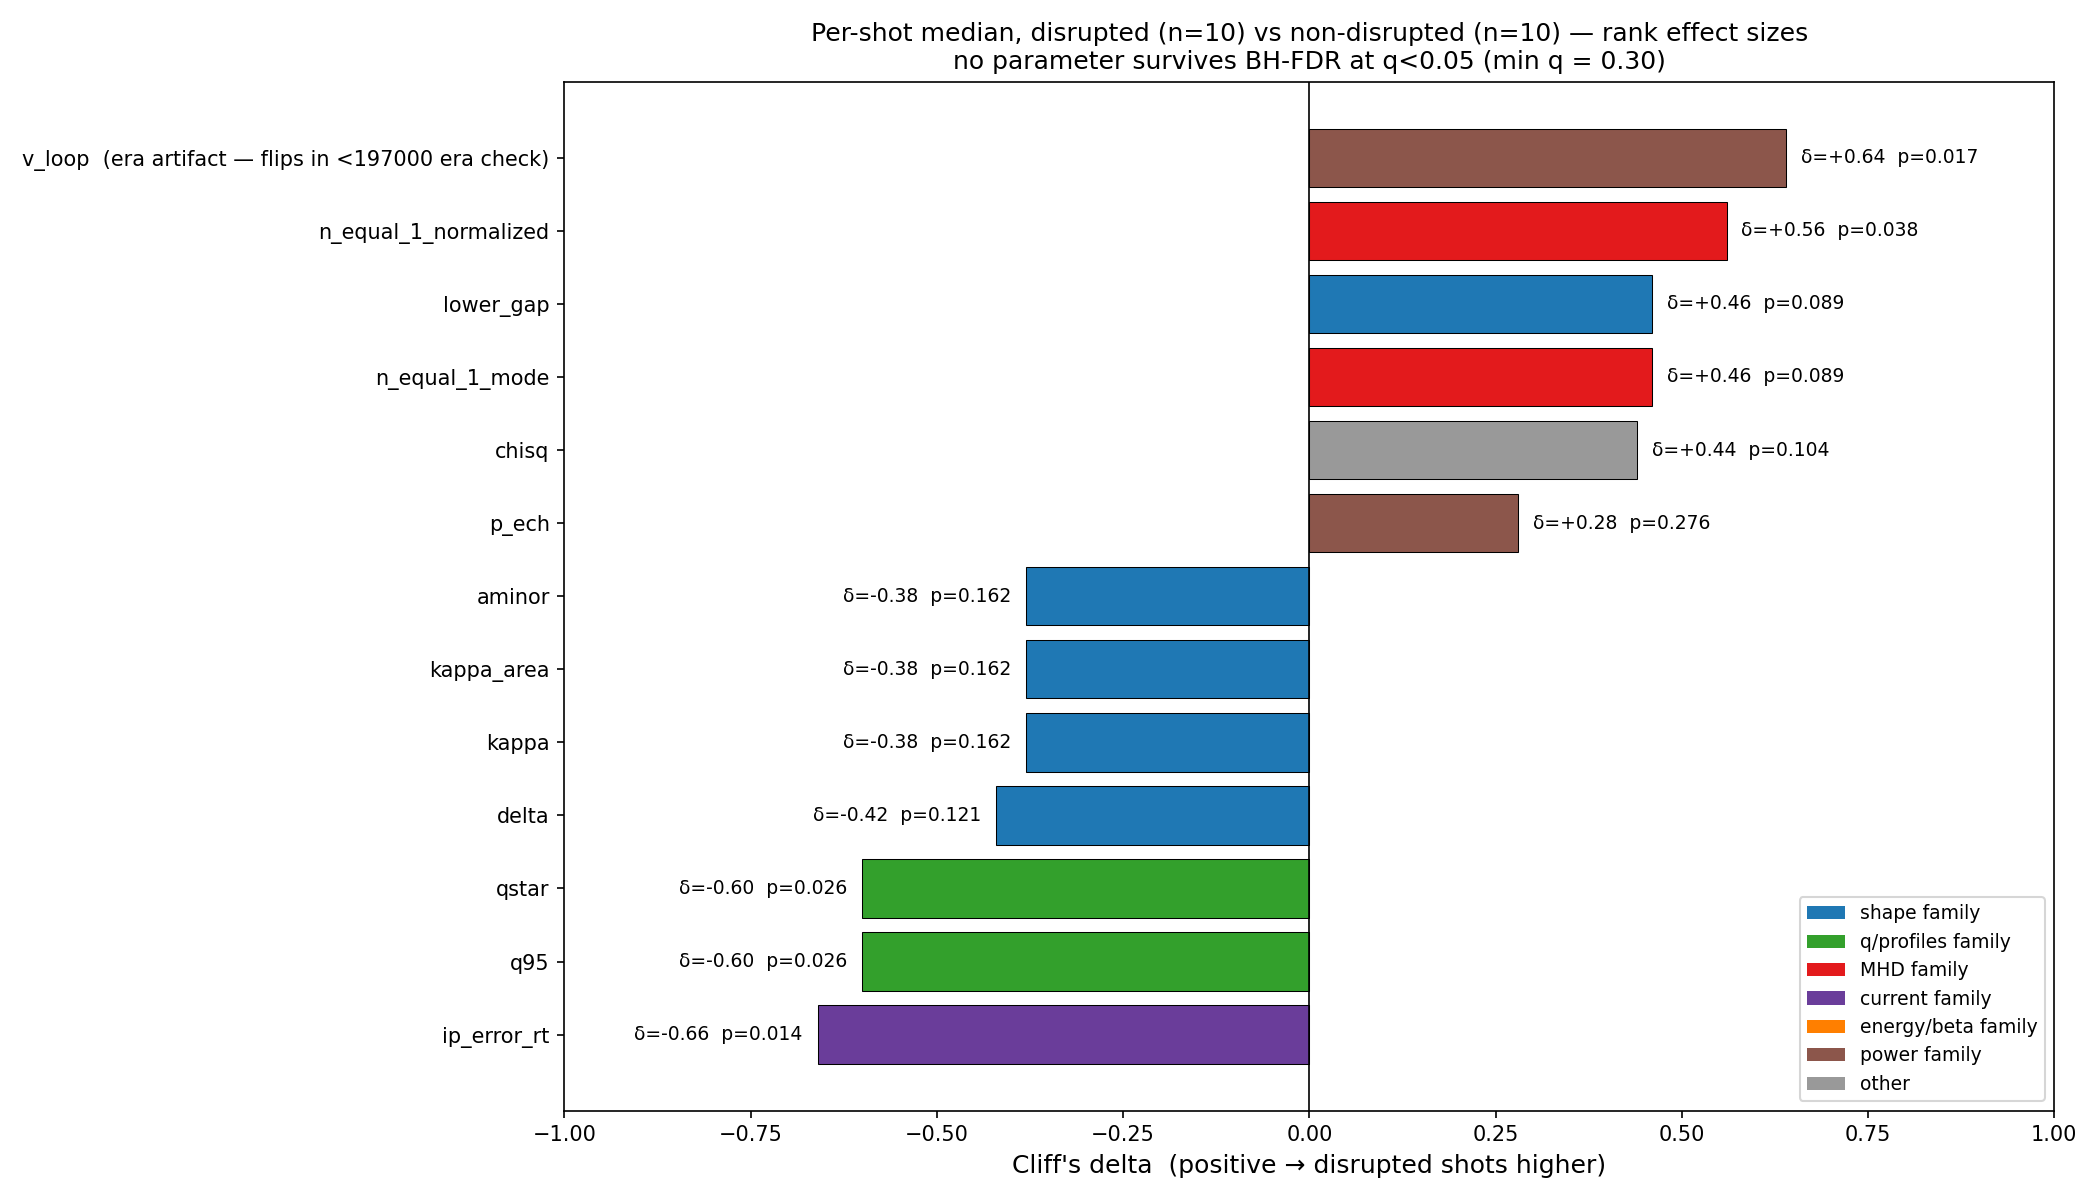

## The headline: nothing is statistically significant

**No parameter survives multiple-comparison correction.** The smallest BH-adjusted q-value across all 47 tested is **0.30** — far above 0.05. With 10 shots per group, even a perfect rank separation would be needed to survive 47 simultaneous tests, and the largest observed effect is |δ| = 0.66. Every difference below should be read as **suggestive, not established** .

## What the suggestive pattern says physically

The directionally-consistent picture is that the disrupted shots ran **closer to classic MHD limits** :

- **Lower q95 and qstar** (3.9 vs 5.6; 5.4 vs 7.5) — lower edge safety factor, nearer the q-limited regime, and consistent with the elongated discharges (lower kappa, 1.53 vs 1.75) that DIII-D ran in that period.
- **~1.5–1.7× higher n=1 mode amplitude** (both raw and normalized) — a locked/slow n=1 mode is a textbook disruption precursor, and it is elevated here even in whole-shot medians, not just near the disruption.
- **Larger lower gap** (0.31 vs 0.17 m) and **near-zero triangularity** (−0.03 vs 0.46) — the disrupted shots are vertically-elongated, low-triangularity plasmas, a shape class known to be more vertical-displacement-event prone.
- **Worse EFIT fit quality** (chisq 26 vs 20) — the equilibrium reconstruction struggles more on these discharges.
- **ECH present only in the disrupted group** (median 768 W vs 0) — a campaign difference, not physics.

## Confounds I checked and how they change the reading

1. **Era/campaign confound** : all 10 disrupted shots are <197000, but half the non-disrupted group is 198xxx–199xxx. Restricting the comparison to the 5 era-matched non-disrupted shots (<197000), **`v_loop` flips direction** (0.81 vs 1.13 V) — it is an era artifact and should be discarded. Every other parameter in the table keeps its direction, and the q95/qstar gap actually widens (3.93 vs 6.29).
2. **Sampling asymmetry** : disrupted shots have denser late-time sampling (39% of rows in their final 20% of indexed time vs 20% for non-disrupted), so their medians lean toward late times. Recomputing medians from the **first half of each shot only** preserves direction for all parameters except `n_equal_1_mode` and `aminor`, which flip — treat those two as fragile. q95, qstar, `n_equal_1_normalized`, gaps, delta and kappa hold in both checks.
3. **`ip_error_rt` is the top-ranked parameter but a compromised column** : I verified earlier it carries a fixed ~204.7× gain (and its sign flips on reversed-Ip shots). The rank test is at the mercy of that sign behavior, so despite the best raw p-value I would not build any claim on it — the mis-scaled column should be replaced by `ip_rt − ip_prog_rt` before trusting it.

## Bottom line

At 10 vs 10 shots, the honest statistical answer is **no parameter differs significantly** after correcting for 47 comparisons. The physically coherent suggestion — lower q, higher n=1 amplitude, elongated low-triangularity shape — is consistent with known disruption phenomenology and survives era and sampling controls, but this balanced 20-shot slice was built as an example dataset, not a campaign population, and cannot establish group separation on its own.

Scripts saved: `disruption_group_comparison_fetch.py`, `disruption_group_comparison_stats.py`, `disruption_group_robustness.py`, `disruption_group_chart.py` (plus the medians/stats JSON sidecars) in the working directory.

In [1]:
%%ask --review
Compare the disrupted shots against the non-disrupted ones in this index.
Which parameters differ most between the two groups? Show the comparison and be
explicit about how many shots are in each group.

---
# 4. Knowing the limits

## How often do DIII-D shots disrupt?

_population · **correctly refused**_

The honest answer is that this dataset cannot say. Twenty shots, deliberately
balanced ten and ten, is not a sample of DIII-D.

In [2]:
%%ask --review
What fraction of DIII-D shots disrupt? Use the disruption index to work
it out.

I'll plan this, re-check the exact query API from my saved scripts, and compute the fraction from the index.

The API is confirmed. Now I'll compute the fraction under both label definitions, plus era breakdowns.

The helper has a dedicated `disruption_rate()` function — the authoritative path for this exact question. Calling it directly.

Both computations are done and the skill's own API confirms the interpretation. Marking the plan complete.

# What Fraction of DIII-D Shots Disrupt?

## The short answer: this data cannot answer that question

The disruption index contains 20 shots, **10 disrupted and 10 non-disrupted** . The arithmetic on the slice is:

**10/20 = 50.0%** (curated `time_until_disrupt` label from the d3drdb disruptions table)

But that 50% is an artifact of how the slice was built, and the index says so explicitly. The skill's own `disruption_rate()` function — which exists precisely for this question — **refuses to return a number** , raising `PopulationClaimUnsupported`:

> *"This index holds 20 shots, 10 of them disrupted — deliberately balanced, not drawn at random from DIII-D. Any rate computed from it (10/20) describes the slice and says nothing about how often DIII-D disrupts. For an archive-wide rate you need the d3drdb disruptions table over a defined shot population, not this file."*

The index metadata carries the same warning as its `coverage_note`. So the honest answer is: **the fraction is 50% for this slice, and that number is meaningless as a DIII-D disruption rate.**

## Why the slice is not a population

- **Deliberately balanced** : the 20 shots were selected 10-and-10, not sampled. A 50/50 split is the construction, not the finding.
- **Era clustering** : all 10 disrupted shots fall in 194xxx–196xxx, while the non-disrupted group includes five 198xxx–199xxx shots. By era the slice gives 10/15 = **66.7%** (early block) vs **0/5** (later block) — two wildly different numbers from the same 20 shots, which is the clearest demonstration that no single fraction from this data is stable.
- **Two campaigns, one gap** : shots 196347 → 198244 is a long jump, so the slice mixes at least two campaign periods with different disruption rates, weighting the "rate" by whatever selection put those specific shots in the file.
- **No denominator definition** : a real disruption rate needs a defined population (all shots? diverted shots only? above some pulse length?), and the index defines none.

## If you need a real DIII-D disruption rate

You would query the **d3drdb disruptions table over a defined shot population** (the human-curated table this index's labels come from), not this file. The `d3d-relational-db` skill serves exactly that: per-shot scalars including disruption time, plus which shots exist in a range and plasma-shot filtering. That path gives you a proper denominator and a defensible fraction. This index, by design, does not.

## What this index *is* good for

The slice was built for **within-shot physics** — the 63 sampled parameters around disruptions, precursor behavior, and label cross-checks (e.g. the 3 curated-vs-derived disagreements on shots 198244, 198643, 199062). Fractions over the archive are outside what it can support.

Scripts saved: `disruption_fraction.py` and `disruption_fraction_rate.py` in the working directory — the second shows the `disruption_rate()` refusal verbatim.

## What can't this dataset answer?

_scope · **answerable**_

In [3]:
%%ask --review
Given everything above, what kinds of questions would this disruption
dataset NOT be able to answer, and what would be needed to answer them?

# What This Disruption Dataset Cannot Answer

The index is a 20-shot, deliberately balanced example slice (10 disrupted / 10 non-disrupted, shots 194000–199687, 3,778 rows) of 63 **global scalar** parameters from disruption-py 0.15.0.dev0, sampled at best every ~2 ms and **stopping at t_disrupt** . Those design facts draw hard boundaries around what it can support. Here are the question classes it cannot answer, and what each would need.

## 1. Archive-scale questions ("what fraction of DIII-D shots disrupt?", "has the rate changed over campaigns?")

**Why not** : the 10/10 split is a construction choice, not a measurement. All 10 disrupted shots sit below 197000 while half the non-disrupted group is 198xxx–199xxx, so the same slice yields 66.7% or 0% depending on how you cut it by era. The index's own `disruption_rate()` raises `PopulationClaimUnsupported` by design — there is no defined denominator here.

**Needed** : the **d3drdb disruptions table queried over a defined shot population** (all plasma shots in a range, with explicit filters — pulse length, configuration, Ip floor). The `d3d-relational-db` skill serves exactly this: shot existence, plasma-shot filtering, and per-shot disruption scalars. A defensible rate requires stating the population, not just counting rows.

## 2. The disruption event itself (thermal quench, current quench, mitigation, runaway electrons, halo currents)

**Why not** : the last sample of every shot sits **at or before** t_disrupt — I verified this on shot 194649, where the final row lands exactly at the disruption time. The thermal quench (~0.1–1 ms) and current quench (~1–10 ms) happen entirely after the data ends, and there is no post-disruption data at all. Halo currents, vessel forces, SPI/MGI mitigation, and runaway-electron platesaus are not even in the parameter list.

**Needed** : raw high-rate diagnostics — **d3d-filterscopes** for the ~50 kHz D-alpha traces (the quench signature), **d3d-shot-fetcher / toksearch-mds** for raw PTDATA Ip and magnetics at kHz rates, plus halo-current sensors and mitigation-system logs that live outside disruption-py's scope entirely.

## 3. Cause attribution ("why did shot X disrupt?")

**Why not** : the 200-ms precursor window on the best-covered shot showed a plasma in apparently good shape — flat Ip, q95 *rising* away from the low-q limit, stored energy *climbing* — right up to the last sample. Whatever initiated that disruption happened on a timescale and spatial scale the index cannot see, and 0-D scalars cannot distinguish competing instabilities.

**Needed** : the full diagnostic set around the event — high-rate magnetics (mode growth and locking), profile diagnostics, radiated power imaging — plus, usually, human review. The index can *motivate* such an investigation (e.g. "194649 disrupts with no precursor in global scalars"), but not complete it.

## 4. Statistical claims about disrupted vs non-disrupted populations (feature ranking, predictor training)

**Why not** : at 10 vs 10 shots, nothing survived multiple-comparison correction — the best Benjamini-Hochberg q-value across 47 parameters was **0.30** — and the suggestive signals are entangled with an era confound (v_loop flips sign once era-matched) and a sampling asymmetry (disrupted shots are sampled more densely late in time).

**Needed** : disruption-py run over **full campaigns** (thousands of shots) with a defined positive/negative population and era-balanced selection. That is the use case disruption-py itself is built for; this file is an example of its output format, not a training set.

## 5. Spatially resolved physics (q-profile evolution, local density/temperature, pedestal, impurity transport)

**Why not** : all 63 columns are global or 0-D — EFIT scalars (q95, wmhd, li, gaps, shape), line-integrated density, total powers, mode amplitudes. There are no profiles of anything.

**Needed** : profile diagnostics (Thomson, CER, ECE) and kinetic/time-dependent EFIT reconstructions; **d3d-shot-fetcher** for psirz flux maps, and the **d3d-elm-phase-analysis** skill if profile samples must be phase-sorted against ELMs.

## 6. Mode structure and rotation (beyond one n=1 amplitude)

**Why not** : the magnetic content is limited to `n1rms`, `n1rms_normalized`, `n_equal_1_mode`, `n_equal_1_normalized` — amplitudes only. No toroidal mode-number spectrum, no mode phase or velocity, no locked-mode phasing, no plasma rotation anywhere in the column list.

**Needed** : raw Mirnov/magnetic probe arrays and charge-exchange recombination spectroscopy via MDSplus (**toksearch-mds** ).

## 7. Anything that depends on the four defective columns

**Why not** : `dipprog_dt` (10⁶ scale error), `ip_error` (numerically identical to `ip`), `time_domain` (constant 1.0) are hard-blocked; `ip_error_rt` is marked usable but carries a verified ~204.7× gain; `radiated_fraction` ranges to −72…+38 and needs clipping. Current-tracking-error studies, phase-binned averages, and absolute radiated-fraction thresholds are all unsupportable as stored.

**Needed** : an upstream disruption-py revision that fixes the `ip_prog` MA-vs-A defect — or compute tracking error directly from `ip_rt − ip_prog_rt` (both sound, both in amperes) and clip `radiated_fraction` yourself.

## 8. Sub-2-ms phenomena and uniform time-base analyses

**Why not** : cadence is mixed — ~25 ms coarse early, ~2 ms fine late — with the switch inside the shot. Anything between samples is invisible, and spectral or correlation work inherits a cadence discontinuity that masquerades as physics.

**Needed** : raw waveforms at native rate (filterscopes ~50 kHz, magnetics via MDSplus) rather than the downsampled index.

## 9. Label truth for the three disagreement shots

**Why not** : shots 198244, 198643 and 199062 are curated as non-disrupted but carry a finite derived `current_quench_time`. The index holds both labels and no adjudication.

**Needed** : inspection of the raw Ip traces against the curation criteria in d3drdb — a data-curation task, not a query this file can settle.

## 10. Operational context ("what experiment was this shot part of?")

**Why not** : the index carries shot numbers, labels and parameters — no campaign, purpose, feedback configuration, or engineering metadata.

**Needed** : the **d3d-relational-db** shot metadata and, for ELM behaviour, the **d3d-elm-index** labels.

## Summary

| Question class | Blocking fact | What's needed |
|---|---|---|
| Archive rates / trends | balanced 20-shot slice, no denominator | d3drdb disruptions table over defined population |
| Quench physics, mitigation, runaways | data stops at t_disrupt; ms-scale events absent | raw high-rate diagnostics (filterscopes, PTDATA, MDSplus) |
| Cause of a specific disruption | 0-D scalars, ≥2 ms, healthy-look precursor window | full diagnostic set + review |
| Population statistics / ML | 10 v 10; min q = 0.30; era + sampling confounds | disruption-py over full campaigns |
| Profiles / spatial physics | 63 global scalars only | Thomson/CER/ECE, kinetic EFIT |
| Mode structure, rotation | amplitude-only n=1 | Mirnov arrays, CER |
| Tracking error, phase binning | 4 defective columns | fixed disruption-py or recompute from `ip_rt`/`ip_prog_rt` |
| Sub-2 ms / spectral work | mixed 25 ms / 2 ms cadence | native-rate waveforms |
| Label adjudication (3 shots) | two labels, no verdict | curation review against raw Ip |
| Campaign context | no metadata | d3drdb shot metadata |

What it **is** fit for: within-shot precursor surveys (with coverage checks — EFIT fill is ~85% and gaps concentrate at shot ends), label cross-checks, parameter semantics and units (its annotation layer is richer than the source NetCDF), and prototyping analyses before scaling them to a real population.